In [5]:
#Contactless ticketing
#Fraud Detection
import numpy as np
import pandas as pd
from math import radians, sin, cos, sqrt, atan2
from datetime import datetime, timedelta

print("Setup complete.")

Setup complete.


In [6]:
#REAL DUBLIN STATION GEOGRAPHY
import numpy as np
import pandas as pd
from math import radians, sin, cos, sqrt, atan2
from datetime import datetime, timedelta

print("Setup complete.")
# REAL DUBLIN STATION GEOGRAPHY (same as the card-based project)

stations = {
    "Connolly": (53.3524, -6.2496), "Abbey Street": (53.3479, -6.2597),
    "Jervis": (53.3479, -6.2680), "Four Courts": (53.3459, -6.2734),
    "Smithfield": (53.3487, -6.2778), "Heuston": (53.3467, -6.2947),
    "St Stephen's Green": (53.3382, -6.2597), "Harcourt": (53.3324, -6.2621),
    "Charlemont": (53.3283, -6.2611), "Sandyford": (53.2799, -6.2029),
    "Tallaght": (53.2880, -6.3728), "Dundrum": (53.2905, -6.2447),
    "Bray": (53.2028, -6.0982), "Dun Laoghaire": (53.2937, -6.1341),
    "Howth": (53.3906, -6.0656), "Malahide": (53.4506, -6.1522),
}
station_names = list(stations.keys())

def haversine_km(c1, c2):
    lat1, lon1, lat2, lon2 = radians(c1[0]), radians(c1[1]), radians(c2[0]), radians(c2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 6371 * 2 * atan2(sqrt(a), sqrt(1-a))

print(f"{len(stations)} stations loaded.")


#GENERATE SYNTHETIC PHONE-TICKETING DATA
# account_id + device_id (instead of just card_id) — the device_id is what
# makes the new multi-device fraud check possible.
# To use real data: replace this cell with your app's actual tap logs.
np.random.seed(42)
n_accounts = 400
n_journeys = 3000
account_ids = [f"ACC-{2000+i}" for i in range(n_accounts)]
device_ids_per_account = {acc: f"DEV-{np.random.randint(10000,99999)}" for acc in account_ids}
start_date = datetime(2026, 1, 1)

records = []
for i in range(n_journeys):
    acc = np.random.choice(account_ids)
    origin, dest = np.random.choice(station_names, 2, replace=False)
    distance = haversine_km(stations[origin], stations[dest])
    speed = np.random.uniform(15, 45)
    duration_min = max((distance / speed) * 60, 3)
    tap_in = start_date + timedelta(days=np.random.randint(0, 90), hours=np.random.randint(6, 23), minutes=np.random.randint(0, 60))
    records.append({
        "account_id": acc, "device_id": device_ids_per_account[acc],
        "tap_in_time": tap_in, "tap_in_station": origin,
        "tap_out_time": tap_in + timedelta(minutes=duration_min), "tap_out_station": dest,
        "distance_km": round(distance, 2), "fare_eur": round(2.0 + distance * 0.15, 2),
        "battery_pct_at_tap": np.random.randint(15, 100),
        "is_true_fraud": False, "fraud_type": None
    })

# Fraud type 1: impossible travel (shared login used far apart) — same logic as card project
for _ in range(8):
    acc = np.random.choice(account_ids)
    s1, s2 = np.random.choice(station_names, 2, replace=False)
    if haversine_km(stations[s1], stations[s2]) < 3:
        continue
    base_time = start_date + timedelta(days=np.random.randint(0, 90), hours=np.random.randint(6, 22))
    second_time = base_time + timedelta(minutes=np.random.uniform(2, 8))
    for t, s, dev in [(base_time, s1, device_ids_per_account[acc]), (second_time, s2, f"DEV-{np.random.randint(10000,99999)}")]:
        records.append({
            "account_id": acc, "device_id": dev, "tap_in_time": t, "tap_in_station": s,
            "tap_out_time": t + timedelta(minutes=5), "tap_out_station": s,
            "distance_km": 0.0, "fare_eur": 2.0, "battery_pct_at_tap": np.random.randint(15,100),
            "is_true_fraud": True, "fraud_type": "impossible_travel"
        })

# Fraud type 2 (NEW — specific to account-based systems): same account, two DIFFERENT
# devices, near-simultaneous taps. A physical card can't do this without cloning;
# a shared phone login can, trivially.
for _ in range(8):
    acc = np.random.choice(account_ids)
    s1, s2 = np.random.choice(station_names, 2, replace=False)
    base_time = start_date + timedelta(days=np.random.randint(0, 90), hours=np.random.randint(6, 22))
    second_time = base_time + timedelta(seconds=np.random.uniform(5, 90))
    dev1 = device_ids_per_account[acc]
    dev2 = f"DEV-{np.random.randint(10000,99999)}"
    for t, s, dev in [(base_time, s1, dev1), (second_time, s2, dev2)]:
        records.append({
            "account_id": acc, "device_id": dev, "tap_in_time": t, "tap_in_station": s,
            "tap_out_time": t + timedelta(minutes=5), "tap_out_station": s,
            "distance_km": 0.0, "fare_eur": 2.0, "battery_pct_at_tap": np.random.randint(15,100),
            "is_true_fraud": True, "fraud_type": "simultaneous_multi_device"
        })

df = pd.DataFrame(records).sort_values("tap_in_time").reset_index(drop=True)
print(f"Total taps: {len(df)}, true fraud events: {df['is_true_fraud'].sum()}")
print(df['fraud_type'].value_counts())

# ============================================================
# PART 4: RUN BOTH FRAUD CHECKS
# ============================================================
MAX_SPEED_KMH = 90

flagged_accounts = set()
flag_details = []

for acc, group in df.groupby("account_id"):
    group = group.sort_values("tap_in_time").reset_index(drop=True)
    for i in range(1, len(group)):
        gap_min = (group.loc[i,"tap_in_time"] - group.loc[i-1,"tap_in_time"]).total_seconds() / 60
        if not (0 < gap_min <= 120):
            continue
        s1, s2 = group.loc[i-1,"tap_in_station"], group.loc[i,"tap_in_station"]
        dev1, dev2 = group.loc[i-1,"device_id"], group.loc[i,"device_id"]
        dist = haversine_km(stations[s1], stations[s2])
        speed = dist / (gap_min / 60) if gap_min > 0 else 0

        # Check 1: impossible travel
        if speed > MAX_SPEED_KMH and dist > 1:
            flagged_accounts.add(acc)
            flag_details.append({"account_id": acc, "check": "impossible_travel",
                                  "gap_min": round(gap_min,2), "distance_km": round(dist,2)})

        # Check 2 (new): same account, different devices, near-simultaneous
        if dev1 != dev2 and gap_min <= 2:
            flagged_accounts.add(acc)
            flag_details.append({"account_id": acc, "check": "simultaneous_multi_device",
                                  "gap_min": round(gap_min,2), "device_1": dev1, "device_2": dev2})

flags_df = pd.DataFrame(flag_details)
print(f"Flagged {len(flagged_accounts)} accounts across {len(flags_df)} individual flag events.")

# ============================================================
# PART 5: HONEST EVALUATION AGAINST KNOWN GROUND TRUTH
# ============================================================
true_fraud_accounts = set(df[df["is_true_fraud"]]["account_id"])
caught = len(true_fraud_accounts & flagged_accounts)
false_positives = flagged_accounts - true_fraud_accounts

recall = caught / len(true_fraud_accounts) * 100
precision = caught / len(flagged_accounts) * 100 if flagged_accounts else 0

print(f"True fraudulent accounts: {len(true_fraud_accounts)}")
print(f"Correctly flagged:        {caught}")
print(f"False positives:          {len(false_positives)}")
print(f"\nCombined recall:    {recall:.0f}%")
print(f"Combined precision: {precision:.0f}%")

print("\n--- By fraud type ---")
for ftype in ["impossible_travel", "simultaneous_multi_device"]:
    true_this_type = set(df[df["fraud_type"]==ftype]["account_id"])
    caught_this_type = len(true_this_type & flagged_accounts)
    print(f"{ftype}: {caught_this_type}/{len(true_this_type)} caught "
          f"({caught_this_type/len(true_this_type)*100:.0f}% recall)")

Setup complete.
16 stations loaded.
Total taps: 3028, true fraud events: 28
fraud_type
simultaneous_multi_device    16
impossible_travel            12
Name: count, dtype: int64
Flagged 14 accounts across 21 individual flag events.
True fraudulent accounts: 14
Correctly flagged:        13
False positives:          1

Combined recall:    93%
Combined precision: 93%

--- By fraud type ---
impossible_travel: 5/6 caught (83% recall)
simultaneous_multi_device: 8/8 caught (100% recall)


Flagged 14 accounts across 21 individual flag events.


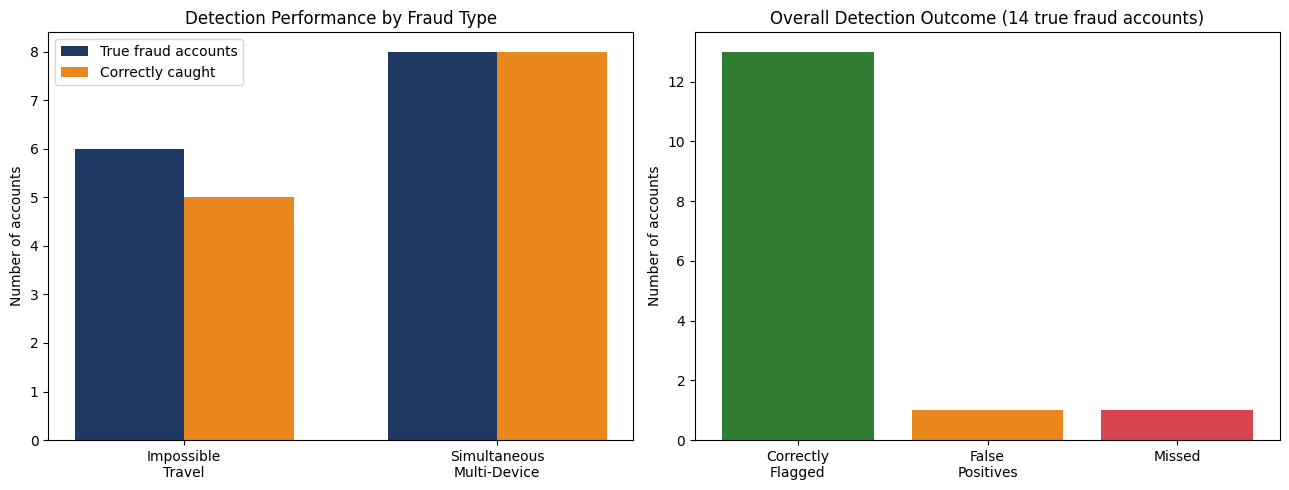

In [4]:
MAX_SPEED_KMH = 90

flagged_accounts = set()
flag_details = []

for acc, group in df.groupby("account_id"):
    group = group.sort_values("tap_in_time").reset_index(drop=True)
    for i in range(1, len(group)):
        gap_min = (group.loc[i,"tap_in_time"] - group.loc[i-1,"tap_in_time"]).total_seconds() / 60
        if not (0 < gap_min <= 120):
            continue
        s1, s2 = group.loc[i-1,"tap_in_station"], group.loc[i,"tap_in_station"]
        dev1, dev2 = group.loc[i-1,"device_id"], group.loc[i,"device_id"]
        dist = haversine_km(stations[s1], stations[s2])
        speed = dist / (gap_min / 60) if gap_min > 0 else 0

        # Check 1: impossible travel
        if speed > MAX_SPEED_KMH and dist > 1:
            flagged_accounts.add(acc)
            flag_details.append({
                "account_id": acc, "check": "impossible_travel",
                "station_1": s1, "station_2": s2,
                "gap_min": round(gap_min,2), "distance_km": round(dist,2)
            })

        # Check 2 (new): same account, different devices, near-simultaneous
        if dev1 != dev2 and gap_min <= 2:
            flagged_accounts.add(acc)
            flag_details.append({
                "account_id": acc, "check": "simultaneous_multi_device",
                "station_1": s1, "station_2": s2,
                "gap_min": round(gap_min,2), "device_1": dev1, "device_2": dev2
            })

flags_df = pd.DataFrame(flag_details)
print(f"Flagged {len(flagged_accounts)} accounts across {len(flags_df)} individual flag events.")

# VISUALISATION 1: Interactive map of flagged fraud events
# (run this after Part 4 — needs `flags_df` to exist)

!pip install -q plotly
import plotly.graph_objects as go

fig = go.Figure()

lats = [c[0] for c in stations.values()]
lons = [c[1] for c in stations.values()]
fig.add_trace(go.Scattermap(
    lat=lats, lon=lons, mode="markers+text", text=station_names,
    textposition="top center", marker=dict(size=8, color="#1F3864"), name="Stations"
))

colors = {"impossible_travel": "#D64550", "simultaneous_multi_device": "#E8871E"}
for _, row in flags_df.iterrows():
    lat1, lon1 = stations[row["station_1"]]
    lat2, lon2 = stations[row["station_2"]]
    fig.add_trace(go.Scattermap(
        lat=[lat1, lat2], lon=[lon1, lon2], mode="lines",
        line=dict(color=colors[row["check"]], width=2), showlegend=False,
        hovertext=f"{row['account_id']}: {row['check']}", hoverinfo="text"
    ))

fig.update_layout(
    map=dict(style="open-street-map", center=dict(lat=53.33, lon=-6.25), zoom=9.5),
    height=650, title="Flagged Fraud Events — Red = Impossible Travel, Orange = Simultaneous Multi-Device",
    margin=dict(l=0, r=0, t=40, b=0)
)
fig.show()

# VISUALISATION 2: Detection results summary
# (all numbers computed from your actual results, nothing hardcoded)
import matplotlib.pyplot as plt
import numpy as np

true_fraud_accounts = set(df[df["is_true_fraud"]]["account_id"])
caught = len(true_fraud_accounts & flagged_accounts)
false_positives = len(flagged_accounts - true_fraud_accounts)
missed = len(true_fraud_accounts - flagged_accounts)

fraud_types = ["impossible_travel", "simultaneous_multi_device"]
true_counts = [len(set(df[df["fraud_type"]==ft]["account_id"])) for ft in fraud_types]
caught_counts = [len(set(df[df["fraud_type"]==ft]["account_id"]) & flagged_accounts) for ft in fraud_types]

fig2, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(fraud_types))
width = 0.35
axes[0].bar(x - width/2, true_counts, width, label="True fraud accounts", color="#1F3864")
axes[0].bar(x + width/2, caught_counts, width, label="Correctly caught", color="#E8871E")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Impossible\nTravel", "Simultaneous\nMulti-Device"])
axes[0].set_title("Detection Performance by Fraud Type")
axes[0].set_ylabel("Number of accounts")
axes[0].legend()

axes[1].bar(
    ["Correctly\nFlagged", "False\nPositives", "Missed"],
    [caught, false_positives, missed],
    color=["#2E7D32", "#E8871E", "#D64550"]
)
axes[1].set_title(f"Overall Detection Outcome ({len(true_fraud_accounts)} true fraud accounts)")
axes[1].set_ylabel("Number of accounts")

plt.tight_layout()
plt.show()